
# AIA to STEREO coordinate conversion

How to convert a point of a source on an AIA image
to a position on a STEREO image.


In [1]:
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import SkyCoord

import sunpy.coordinates
import sunpy.map
# from sunpy.data.sample import AIA_193_JUN2012, STEREO_A_195_JUN2012
from sunpy.sun import constants

In [2]:
# Replace the sample files with my files
import glob
import re
from sunpy.time import parse_time
import os
import numpy as np

data_dir = '/home/mnedal/data'
date     = '2025-10-06'

aia_channel  = 193
euvi_channel = 195

def load_channel(channel=None, date=None, data_dir=None, inst=None):
    """Load local files for one channel per instrument as a list of fits/fts files."""
    y, m, d = date.split('-')
    if inst == 'aia':
        files = sorted(glob.glob(
            f'{data_dir}/AIA/{channel}A/highres/lv15/'
            f'aia.lev15.{channel}A_{y}_{m}_{d}T*_lev15*.fits'))
    elif inst == 'euvi':
        files = sorted(glob.glob(
            f'{data_dir}/SECCHI/{channel}A/'
            f'{y}{m}{d}_*.fts'))
    if not files:
        raise FileNotFoundError(f'No files for {inst}-{channel} A on {date}.')
    return files


aia_files  = load_channel(channel=aia_channel, date=date, data_dir=data_dir, inst='aia')
euvi_files = load_channel(channel=euvi_channel, date=date, data_dir=data_dir, inst='euvi')

target_time = parse_time(f'{date}T08:47:30')


def time_from_filename(path, inst):
    """Extract observation time from a local AIA/EUVI filename as parse_time."""
    name = os.path.basename(path)
    if inst == 'aia':
        # ...193A_2025_10_06T08_31_04.84Z.image_lev15.fits
        m = re.search(r'_(\d{4})_(\d{2})_(\d{2})T(\d{2})_(\d{2})_(\d{2}(?:\.\d+)?)Z', name)
        y, mo, d, H, M, S = m.groups()
        return parse_time(f'{y}-{mo}-{d}T{H}:{M}:{S}')
    elif inst == 'euvi':
        # 20251006_084730_n4euA.fts
        m = re.search(r'(\d{8})_(\d{6})', name)
        ymd, hms = m.groups()
        return parse_time(f'{ymd[:4]}-{ymd[4:6]}-{ymd[6:8]}'
                          f'T{hms[:2]}:{hms[2:4]}:{hms[4:6]}')

target_time = parse_time(f'{date}T08:47:30')

aia_times  = [time_from_filename(f, 'aia')  for f in aia_files]
euvi_times = [time_from_filename(f, 'euvi') for f in euvi_files]

i_aia  = int(np.argmin([abs((t - target_time).to_value('s')) for t in aia_times]))
i_euvi = int(np.argmin([abs((t - target_time).to_value('s')) for t in euvi_times]))

aia_file  = aia_files[i_aia]
euvi_file = euvi_files[i_euvi]

aia_file, euvi_file

('/home/mnedal/data/AIA/193A/highres/lv15/aia.lev15.193A_2025_10_06T08_47_28.85Z.image_lev15.fits',
 '/home/mnedal/data/SECCHI/195A/20251006_084730_n4euA.fts')

Create a dictionary with the two maps, cropped down to full disk.



In [3]:
maps = {m.detector: m.submap(SkyCoord([-1100, 1100]*u.arcsec,
                                      [-1100, 1100]*u.arcsec,
                                      frame=m.coordinate_frame))
        for m in sunpy.map.Map([aia_file, euvi_file])}
maps['AIA'].plot_settings['vmin'] = 0  # set the minimum plotted pixel value

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


We will be transforming coordinates where the formation height of 304 A
emission makes a difference, so we set the reference solar radius to 4 Mm
above the solar surface (see :cite:t:`alissandrakis_measurement_2019`).



In [4]:
for m in maps.values():
    m.meta['rsun_ref'] = (constants.radius + 4*u.Mm).to_value('m')

Plot both maps.



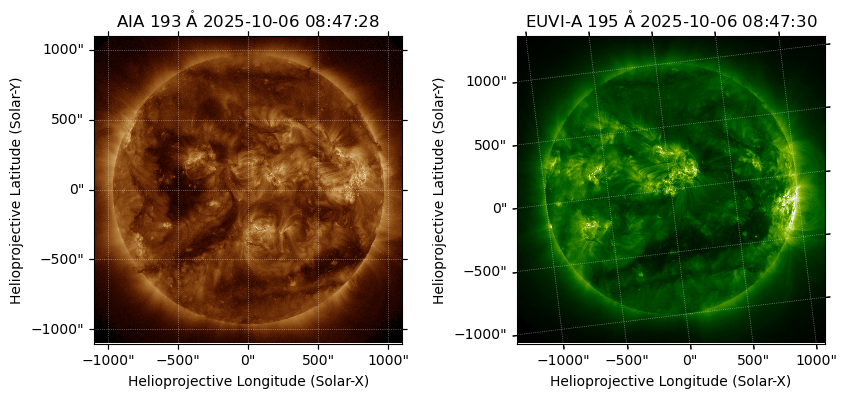

In [5]:
fig = plt.figure(figsize=(10, 4))
for i, m in enumerate(maps.values()):
    ax = fig.add_subplot(1, 2, i+1, projection=m)
    m.plot(axes=ax)

We are now going to pick out a region around the south west corner:



In [6]:
aia_bottom_left = SkyCoord(-120 * u.arcsec,
                           -200 * u.arcsec,
                           frame=maps['AIA'].coordinate_frame)
aia_top_right = SkyCoord(500 * u.arcsec,
                         400 * u.arcsec,
                         frame=maps['AIA'].coordinate_frame)

Plot a rectangle around the region we want to crop.



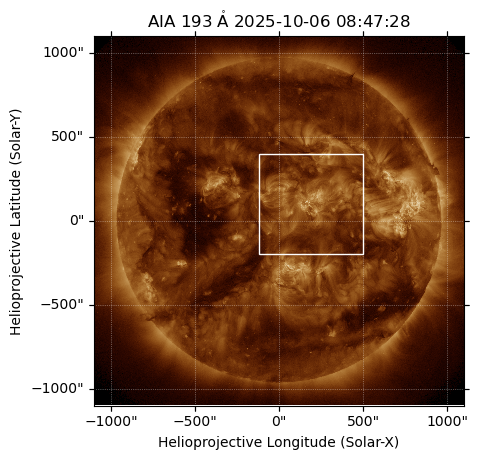

In [7]:
fig = plt.figure()
ax = fig.add_subplot(projection=maps['AIA'])
maps['AIA'].plot(axes=ax)
maps['AIA'].draw_quadrangle(aia_bottom_left, top_right=aia_top_right)
plt.show()

Create a submap of this area and draw an X at a specific feature of interest.



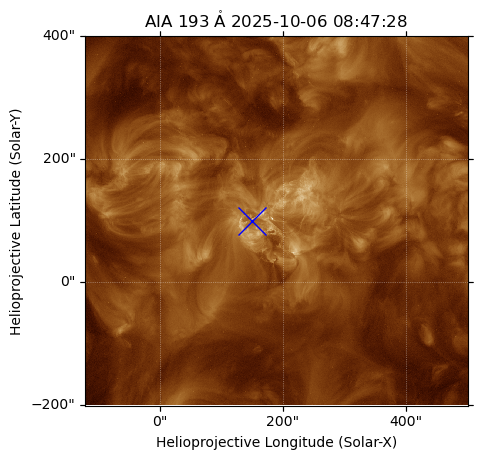

In [8]:
subaia = maps['AIA'].submap(aia_bottom_left, top_right=aia_top_right)

fig = plt.figure()
ax = fig.add_subplot(projection=subaia)
subaia.plot(axes=ax)
feature_aia = SkyCoord(150 * u.arcsec,
                       100 * u.arcsec,
                       frame=maps['AIA'].coordinate_frame)
ax.plot_coord(feature_aia, 'bx', fillstyle='none', markersize=20)
plt.show()

We can transform the coordinate of the feature to see its representation as
seen by STEREO EUVI. The original coordinate did not contain a distance from
the observer, so it is converted to a 3D coordinate assuming that it has a
radius from Sun center equal to the reference solar radius of the coordinate
frame, which we set earlier to be the formation height of 304 A emission.



In [9]:
print(feature_aia.transform_to(maps['EUVI'].coordinate_frame))

<SkyCoord (Helioprojective: obstime=2025-10-06T08:47:34.008, rsun=699700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2025-10-06T08:47:34.008, rsun=699700.0 km): (lon, lat, radius) in (deg, deg, m)
    (48.39382581, 1.72240398, 1.44367204e+11)>): (Tx, Ty, distance) in (arcsec, arcsec, m)
    (-620.69679197, 190.40137377, 1.43834427e+11)>


Now we can plot this box on both the AIA and EUVI images. Note that using
:meth:`~sunpy.map.GenericMap.draw_quadrangle` means that the plotted
rectangle will be automatically warped appropriately to account for the
different coordinate frames.



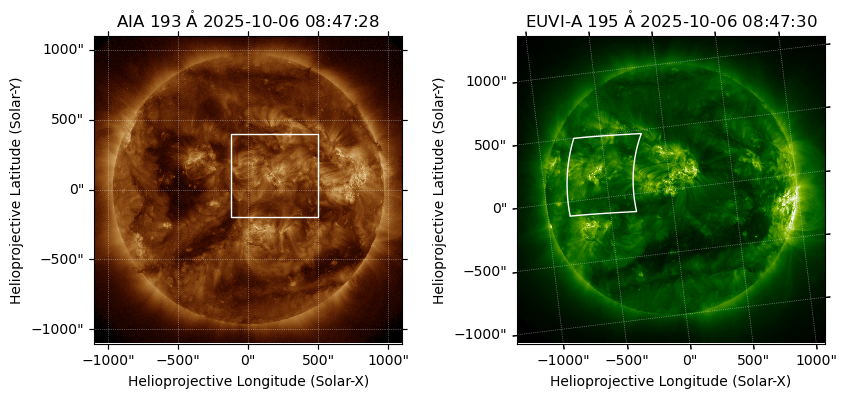

In [10]:
fig = plt.figure(figsize=[10,4])

ax1 = fig.add_subplot(121, projection=maps['AIA'])
maps['AIA'].plot(axes=ax1)
maps['AIA'].draw_quadrangle(aia_bottom_left, top_right=aia_top_right, axes=ax1)

ax2 = fig.add_subplot(122, projection=maps['EUVI'])
maps['EUVI'].plot(axes=ax2)
maps['AIA'].draw_quadrangle(aia_bottom_left, top_right=aia_top_right, axes=ax2)

plt.show()

We can now zoom in on the region in the EUVI image, and we also draw an X
at the feature marked earlier. We do not need to explicitly transform the
feature coordinate to the matching coordinate frame; that is performed
automatically by :meth:`~astropy.visualization.wcsaxes.WCSAxes.plot_coord`.



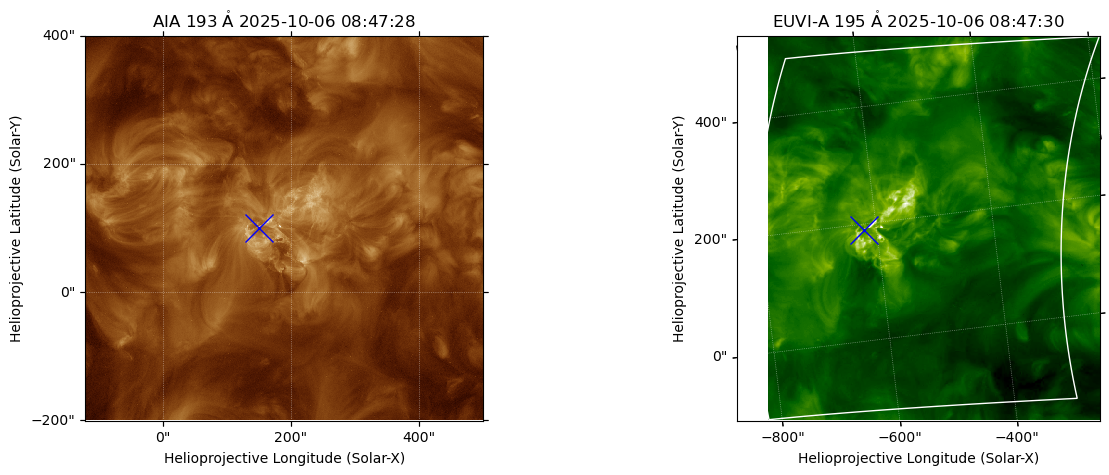

In [11]:
fig = plt.figure(figsize=[15,5])

ax1 = fig.add_subplot(121, projection=subaia)
subaia.plot(axes=ax1)
ax1.plot_coord(feature_aia, 'bx', fillstyle='none', markersize=20)

subeuvi = maps['EUVI'].submap(aia_bottom_left, top_right=aia_top_right)

ax2 = fig.add_subplot(122, projection=subeuvi)
subeuvi.plot(axes=ax2)
maps['AIA'].draw_quadrangle(aia_bottom_left, top_right=aia_top_right, axes=ax2)
ax2.plot_coord(feature_aia, 'bx', fillstyle='none', markersize=20)

plt.show()

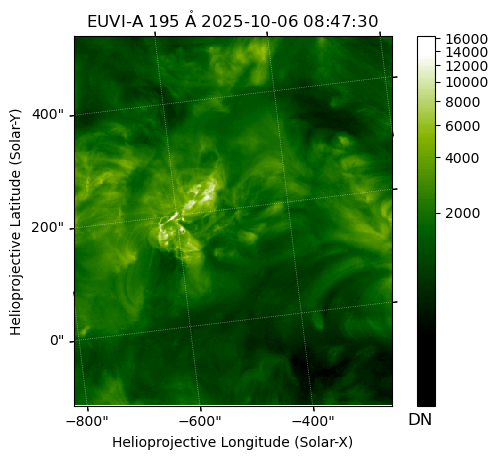

In [12]:
subeuvi.peek()

---
# J-map analysis on running difference / ratio EUVI maps

This section replicates the AIA J-map workflow (`plot_jmap_AIA`) for STEREO/EUVI,
reusing the same methods: build a running-**difference** or running-**ratio** time
series of the region of interest, lay a fan of radial slits whose origin is the
feature marked on AIA (`feature_aia`, transformed automatically into the EUVI
frame), build distance--time (J-) plots per slit, manually trace a moving feature
repeatedly for an uncertainty estimate, and derive its kinematics
(distance, speed, acceleration).

The coordinate-conversion cells above are left unchanged. Everything below reuses
`maps`, `feature_aia`, `euvi_files`, `euvi_times`, `date` and `data_dir` defined there.

**Workflow**
1. Edit the single **Configuration** block; nothing else needs touching.
2. Run the function-definition cells once.
3. Run the *build sequence* cell to produce the running diff/ratio EUVI series and slit traces.
4. For each slit: set `ACTIVE_SLIT_ID`, run the interactive cell, left-click the
   feature, right-click to store one repeat (`N_REPEATS` times), then move to the next slit.
5. Aggregate, save, and plot.

The interactive trace collection needs an interactive backend (`%matplotlib widget`).


In [13]:
# Interactive backend is required for the manual feature tracing further down.
%matplotlib widget
# Non-interactive alternative (no clicking): %matplotlib inline

import logging

import pandas as pd
import matplotlib.dates as mdates
import matplotlib.colors as colors

from scipy.ndimage import map_coordinates
from scipy.signal import savgol_filter

import sunpy.sun.constants as const

from tqdm import tqdm

# Quieten SunPy's logger so the long sequence loops stay readable.
sunpy.log.setLevel(logging.WARNING)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'


def save_fig(fig, savepath, dpi=300):
    """Publication export: tight bounding box, minimal whitespace. No-op if savepath is None."""
    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches='tight', pad_inches=0.02)


## Configuration

The only block to edit. Everything downstream reads from these names, so a slit,
feature, region, method, or time window is changed here rather than inline.


In [42]:
# --- Instrument / event -------------------------------------------------------
# `date`, `data_dir`, `euvi_channel`, `euvi_files`, `euvi_times` and `maps` all
# come from the coordinate-conversion cells above.
EUVI_CHANNEL = euvi_channel                    # 195 A, as loaded above

# Region of interest, given in AIA helioprojective arcsec (the same box used in
# the conversion above). It is transformed into the EUVI frame automatically for
# cropping, so the slit fan sits on the same physical region in both instruments.
ROI_AIA = dict(left=-120, right=500, bottom=-200, top=400)

# --- Running difference / ratio ----------------------------------------------
METHOD      = 'ratio'                          # 'ratio' | 'difference'  (single switch)
RATIO_LAG   = 1                                # frame vs frame-(LAG); LAG x cadence = baseline
DENOM_FLOOR = 1.0                              # ratio only: NaN out denominators below this

# Display scaling for the processed EUVI maps.
RATIO_SCALE     = dict(gamma=0.5, lo=0.5, hi=2.0)   # PowerNorm window for METHOD='ratio'
DIFF_PERCENTILE = (1, 99)                            # symmetric clip for METHOD='difference'

# --- Time sequence used to build the J-plots ----------------------------------
# EUVI cadence is coarse and often irregular, so the sequence is built from the
# actual EUVI frame times that fall inside this window (not a fixed-frequency grid).
SEQ_START = f'{date}T08:00:00'
SEQ_END   = f'{date}T10:00:00'

# --- Slit geometry (radial fan from one origin) -------------------------------
# Origin defaults to feature_aia transformed into the EUVI frame (set in the build
# cell). Set SLIT_START_XY_EUVI to an explicit (Tx, Ty) in EUVI arcsec to override.
SLIT_START_XY_EUVI = None
SLIT_ANGLES_DEG    = np.arange(170, 300, 15)    # CCW from solar West
SLIT_LENGTH_ARCSEC = 280
N_SAMPLES          = 300                        # points sampled along each slit

# --- J-plot display window ----------------------------------------------------
DISTANCE_UNIT = 'Mm'                           # 'Mm' (required for kinematics) or 'arcsec'
JPLOT_TLIM    = None                           # e.g. (f'{date}T08:40:00', f'{date}T09:30:00')
JPLOT_DLIM    = None                           # e.g. (30, 200) in DISTANCE_UNIT
JPLOT_CMAP    = 'Greys_r'

# --- Feature tracing ----------------------------------------------------------
FEATURE_ID = 'front_00'                        # label for the traced feature
N_REPEATS  = 5                                 # repeated manual traces per slit

# --- Kinematics smoothing -----------------------------------------------------
SAVGOL_WINDOW    = 5
SAVGOL_POLYORDER = 2

# --- Reference frame for the slit-overlay preview -----------------------------
REF_DATETIME = f'{date}T08:47:30'              # nearest sequence frame is used

# --- Plot display / export ----------------------------------------------------
SHOW_TITLES = True
SAVE_FIGS   = True
FIG_DIR     = './plots'
FIG_DPI     = 300

# --- Output -------------------------------------------------------------------
OUTPUT_DIR  = './outputs'

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Event {date} | EUVI {EUVI_CHANNEL} A | method: running {METHOD}')


Event 2025-10-06 | EUVI 195 A | method: running ratio


## Core: load the EUVI sequence and build running diff/ratio maps


In [43]:
def load_euvi_sequence(files):
    """Load the EUVI file list (already gathered above) as a time-ordered MapSequence."""
    return sunpy.map.Map(files, sequence=True)


def running_map(sequence, target_time, lag=1, method='ratio', denom_floor=1.0):
    """Running-difference or running-ratio of the frame nearest target_time against
    the frame `lag` steps earlier.

    Returns (processed_map, current_frame_time). The single `method` switch is the
    same one that would be applied to AIA: 'ratio' divides, 'difference' subtracts.
    """
    t   = parse_time(target_time)
    idx = int(np.argmin([abs(mp.date - t) for mp in sequence.maps]))
    if idx < lag:
        raise ValueError(f'Frame {idx} has no frame {lag} step(s) earlier.')
    cur, prev = sequence[idx], sequence[idx - lag]

    if method == 'ratio':
        # NaN out near-zero/off-limb denominators so they map to neutral rather than blow up.
        denom = np.where(prev.data > denom_floor, prev.data, np.nan)
        data  = cur.data / denom
    elif method == 'difference':
        data  = cur.data.astype(float) - prev.data.astype(float)
    else:
        raise ValueError("method must be 'ratio' or 'difference'.")

    pmap = sunpy.map.Map(data, cur.meta)
    pmap.plot_settings['norm'] = colors.Normalize()  # avoid inherited-stretch repr crash
    return pmap, cur.date


def roi_corners_in_frame(roi_aia, src_map, dst_map):
    """Transform an AIA-arcsec ROI box into dst_map's frame; return (bottom_left, top_right)."""
    bl = SkyCoord(roi_aia['left']  * u.arcsec, roi_aia['bottom'] * u.arcsec,
                  frame=src_map.coordinate_frame).transform_to(dst_map.coordinate_frame)
    tr = SkyCoord(roi_aia['right'] * u.arcsec, roi_aia['top']    * u.arcsec,
                  frame=src_map.coordinate_frame).transform_to(dst_map.coordinate_frame)
    return bl, tr


## Slit geometry

A fan of straight radial slits sharing one origin (the EUVI-frame position of
`feature_aia`). Each slit is stored as a two-point `SkyCoord` (start, end) in the
EUVI map's frame. Same method as the AIA notebook.


In [44]:
def make_hpc_coord(x_arcsec, y_arcsec, map_obj):
    """SkyCoord at (x, y) arcsec in the coordinate frame of map_obj."""
    return SkyCoord(x_arcsec * u.arcsec, y_arcsec * u.arcsec,
                    frame=map_obj.coordinate_frame)


def make_slit(start_xy, angle_deg, length_arcsec, map_obj):
    """One straight slit from start_xy at angle_deg (CCW from solar West).

    Returns a two-point SkyCoord [start, end].
    """
    x0, y0 = start_xy
    angle_rad = np.deg2rad(angle_deg)
    x1 = x0 + length_arcsec * np.cos(angle_rad)
    y1 = y0 + length_arcsec * np.sin(angle_rad)
    start = make_hpc_coord(x0, y0, map_obj)
    end   = make_hpc_coord(x1, y1, map_obj)
    return SkyCoord([start, end])


def make_slit_grid(start_xy, angles_deg, length_arcsec, map_obj):
    """Build a dict of slits {('slit_NN'): {angle, start_xy, length, line}}."""
    slits = {}
    for i, angle in enumerate(angles_deg):
        slit_id = f'slit_{i + 1:02d}'   # 1-based numbering
        slits[slit_id] = {
            'angle_deg': angle,
            'start_xy': start_xy,
            'length_arcsec': length_arcsec,
            'line': make_slit(start_xy, angle, length_arcsec, map_obj),
        }
    return slits


## Sampling intensity along a slit and per-frame processing


In [45]:
def sample_map_along_slit(map_obj, slit_line, n_samples=300, order=1):
    """Interpolate map values along a slit.

    Returns (distances_arcsec, intensities, coords). Distances are measured from
    the slit start. `order` is the map_coordinates interpolation order
    (0 = nearest, 1 = linear).
    """
    start, end = slit_line[0], slit_line[1]

    x_vals = np.linspace(start.Tx.to_value(u.arcsec),
                         end.Tx.to_value(u.arcsec), n_samples)
    y_vals = np.linspace(start.Ty.to_value(u.arcsec),
                         end.Ty.to_value(u.arcsec), n_samples)

    coords = SkyCoord(x_vals * u.arcsec, y_vals * u.arcsec,
                      frame=map_obj.coordinate_frame)

    px, py = map_obj.world_to_pixel(coords)
    intensities = map_coordinates(
        map_obj.data.astype(float),
        [py.to_value(u.pix), px.to_value(u.pix)],
        order=order, mode='constant', cval=np.nan,
    )

    distances_arcsec = np.sqrt((x_vals - x_vals[0])**2 + (y_vals - y_vals[0])**2)
    return distances_arcsec, intensities, coords


def process_one_frame(sequence, target_time, roi_corners,
                      lag=1, method='ratio', denom_floor=1.0):
    """Build one cropped running diff/ratio EUVI frame."""
    pmap, frame_time = running_map(sequence, target_time, lag=lag,
                                   method=method, denom_floor=denom_floor)
    bl, tr = roi_corners
    cropped = pmap.submap(bl, top_right=tr)
    return {
        'target_time': target_time,
        'frame_time': frame_time,
        'proc_map': pmap,
        'cropped_map': cropped,
        'ref_map': cropped,
    }


def trace_slits_for_frame(frame_result, slits, n_samples=300):
    """Sample every slit on the single (cropped) EUVI map of one processed frame."""
    traces = {}
    mp = frame_result['cropped_map']
    for slit_id, slit in slits.items():
        distance, intensity, coords = sample_map_along_slit(
            mp, slit['line'], n_samples=n_samples)
        traces[slit_id] = {
            'angle_deg': slit['angle_deg'],
            'start_xy': slit['start_xy'],
            'length_arcsec': slit['length_arcsec'],
            'distance_arcsec': distance,
            'intensity': intensity,
            'coords': coords,
        }
    return traces


## Process the full time sequence

Builds a processed EUVI frame at every sequence time and traces all slits through
each frame. The slit grid is created once, on the first frame's reference map, and
reused so distances are consistent across the sequence. Frames with no baseline
`lag` steps earlier are skipped.


In [46]:
def process_slit_sequence(sequence, target_times, roi_corners,
                          start_xy, angles_deg, length_arcsec,
                          lag=1, method='ratio', denom_floor=1.0, n_samples=300):
    """Process many frames and trace slits through all of them."""
    results = {'frames': {}, 'traces': {}, 'slits': None, 'target_times': target_times}

    for target_time in tqdm(target_times, desc='Processing EUVI J-map sequence'):
        try:
            frame = process_one_frame(
                sequence=sequence, target_time=target_time, roi_corners=roi_corners,
                lag=lag, method=method, denom_floor=denom_floor)
        except ValueError as e:
            print(f'Skipping {target_time}: {e}')
            continue

        if results['slits'] is None:
            results['slits'] = make_slit_grid(
                start_xy=start_xy, angles_deg=angles_deg,
                length_arcsec=length_arcsec, map_obj=frame['ref_map'])

        results['frames'][target_time] = frame
        results['traces'][target_time] = trace_slits_for_frame(
            frame_result=frame, slits=results['slits'], n_samples=n_samples)

    return results


## EUVI preview with slit overlay


In [47]:
def display_norm(data, method='ratio', ratio_scale=None, diff_percentile=(1, 99)):
    """Pick a sensible display normalization for a processed map."""
    if method == 'ratio':
        rs = ratio_scale or {}
        return colors.PowerNorm(gamma=rs.get('gamma', 0.5),
                                vmin=rs.get('lo', 0.5), vmax=rs.get('hi', 2.0), clip=True)
    # difference: symmetric about zero so positive/negative read evenly.
    vmin, vmax = np.nanpercentile(data, diff_percentile)
    m = max(abs(vmin), abs(vmax))
    return colors.Normalize(vmin=-m, vmax=m)


def plot_map_with_slits(proc_map, slits=None, method='ratio', ratio_scale=None,
                        diff_percentile=(1, 99), title='', cmap='Greys_r',
                        slit_colour='red', slit_lw=1, label_offset_arcsec=15,
                        show_title=True, savepath=None, dpi=300):
    """Show a processed EUVI frame, optionally overlaying slits labelled near their tips."""
    norm = display_norm(proc_map.data, method, ratio_scale, diff_percentile)

    fig = plt.figure(figsize=[7, 7])
    ax = fig.add_subplot(projection=proc_map)
    ax.imshow(proc_map.data, origin='lower', cmap=cmap, norm=norm)
    ax.grid(False)

    if slits is not None:
        for slit_id, slit in slits.items():
            line = slit['line']
            ax.plot_coord(line, color=slit_colour, linestyle='-', lw=slit_lw, alpha=0.7)

            start, end = line[0], line[1]
            dx = end.Tx.to_value(u.arcsec) - start.Tx.to_value(u.arcsec)
            dy = end.Ty.to_value(u.arcsec) - start.Ty.to_value(u.arcsec)
            norm_len = np.hypot(dx, dy)
            ux, uy = (0, 0) if norm_len == 0 else (dx / norm_len, dy / norm_len)

            label_coord = SkyCoord(
                (end.Tx.to_value(u.arcsec) + label_offset_arcsec * ux) * u.arcsec,
                (end.Ty.to_value(u.arcsec) + label_offset_arcsec * uy) * u.arcsec,
                frame=proc_map.coordinate_frame)

            slit_number = int(slit_id.split('_')[-1])
            ax.text_coord(label_coord, slit_number, color=slit_colour,
                          fontsize=10, fontweight='bold', ha='center', va='center')

    if show_title:
        ax.set_title(title)
    ax.set_xlabel('Solar X [arcsec]')
    ax.set_ylabel('Solar Y [arcsec]')
    save_fig(fig, savepath, dpi=dpi)
    return fig, ax


## Build and plot a J-plot for one slit


In [48]:
def arcsec_to_Mm_factor(ref_map):
    """arcsec -> Mm using the map's observed solar radius (physical R_sun / R_sun_obs).

    Uses the EUVI map's own rsun_obs, so the STEREO-A viewing distance is handled.
    """
    rsun_obs_arcsec = ref_map.rsun_obs.to_value(u.arcsec)
    rsun_Mm = const.radius.to_value(u.Mm)
    return rsun_Mm / rsun_obs_arcsec


def build_jplot(results, slit_id, distance_unit='Mm'):
    """Stack per-frame intensity traces into a [n_times, n_distances] J-plot array.

    Returns (jplot, times, distances, distance_label).
    """
    times = list(results['traces'].keys())
    rows = [results['traces'][t][slit_id]['intensity'] for t in times]
    jplot = np.asarray(rows)

    distances_arcsec = results['traces'][times[0]][slit_id]['distance_arcsec']

    if distance_unit == 'arcsec':
        distances = distances_arcsec
        distance_label = 'Distance along slit [arcsec]'
    elif distance_unit == 'Mm':
        ref_map = results['frames'][times[0]]['ref_map']
        distances = distances_arcsec * arcsec_to_Mm_factor(ref_map)
        distance_label = 'Distance along slit [Mm]'
    else:
        raise ValueError("distance_unit must be 'arcsec' or 'Mm'.")

    return jplot, times, distances, distance_label


def plot_jplot(results, slit_id, distance_unit='Mm',
               xlim=None, ylim=None, vmin=None, vmax=None,
               percentile=(1, 99), cmap='Greys_r',
               title=None, show_title=True, savepath=None, dpi=300):
    """Plot a distance--time J-plot for one slit.

    Returns (fig, ax, jplot, times, distances).
    """
    jplot, times, distances, distance_label = build_jplot(
        results, slit_id=slit_id, distance_unit=distance_unit)

    time_nums = mdates.date2num(pd.to_datetime(times))
    if vmin is None or vmax is None:
        vmin, vmax = np.nanpercentile(jplot, percentile)

    fig, ax = plt.subplots(figsize=[8, 6])
    mesh = ax.pcolormesh(time_nums, distances, jplot.T, shading='auto',
                         cmap=cmap, vmin=vmin, vmax=vmax)

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

    if xlim is not None:
        ax.set_xlim(*mdates.date2num(pd.to_datetime(list(xlim))))
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel('Time [UT]')
    ax.set_ylabel(distance_label)
    if show_title:
        ax.set_title(title if title is not None else f'{slit_id} | EUVI {EUVI_CHANNEL} A | running {METHOD}')
    fig.colorbar(mesh, ax=ax, pad=0.01, label=f'Running-{METHOD} intensity')
    fig.autofmt_xdate()
    save_fig(fig, savepath, dpi=dpi)
    return fig, ax, jplot, times, distances


## Interactive feature tracing on a J-plot

Left-click to add points to the current trace; right-click to store it and reset
for the next repeat. After `n_repeats` stored traces the handler disconnects.
Repeats give a spread that becomes the standard error on the kinematics.


In [49]:
def collect_repeated_jplot_traces(fig, ax, slit_id, feature_id='front_00',
                                  n_repeats=5, storage=None, y_unit='Mm',
                                  marker='x', line_style='-', show_title=True):
    """Collect repeated manual traces of a moving feature on a J-plot.

    Storage layout: storage[slit_id][feature_id] = {'y_unit', 'repeats': [...]}.
    Pass an existing `storage` dict to accumulate across slits.
    """
    if storage is None:
        storage = {}
    storage.setdefault(slit_id, {})
    storage[slit_id].setdefault(feature_id, {'y_unit': y_unit, 'repeats': []})

    current_trace = {'x_time_num': [], 'x_time': [], 'y_distance': []}
    current_artists = []

    def update_title():
        """Show which repeat is in progress (or completion) in the J-plot title."""
        if not show_title:
            return
        done = len(storage[slit_id][feature_id]['repeats'])
        if done >= n_repeats:
            ax.set_title(f'{slit_id} | {feature_id} | {n_repeats}/{n_repeats} repeats done')
        else:
            ax.set_title(f'{slit_id} | {feature_id} | repeat {done + 1}/{n_repeats}')
        fig.canvas.draw_idle()

    def redraw_current_trace():
        nonlocal current_artists
        for artist in current_artists:
            artist.remove()
        current_artists = []

        x, y = current_trace['x_time_num'], current_trace['y_distance']
        if len(x) == 0:
            fig.canvas.draw_idle()
            return

        point_artist, = ax.plot(x, y, linestyle='None', marker=marker,
                                ms=7, mew=1.5, color='red')
        current_artists.append(point_artist)
        if len(x) > 1:
            line_artist, = ax.plot(x, y, linestyle=line_style, lw=1.5, alpha=0.8, color='red')
            current_artists.append(line_artist)
        fig.canvas.draw_idle()

    def clear_current_trace_from_plot():
        nonlocal current_artists
        for artist in current_artists:
            artist.remove()
        current_artists = []
        fig.canvas.draw_idle()

    def reset_current_trace():
        current_trace['x_time_num'] = []
        current_trace['x_time'] = []
        current_trace['y_distance'] = []

    def onclick(event):
        nonlocal cid
        if event.inaxes != ax or event.xdata is None or event.ydata is None:
            return

        repeats = storage[slit_id][feature_id]['repeats']
        repeat_number = len(repeats) + 1

        if event.button == 1:        # left click: add a point
            x_num, y_val = event.xdata, event.ydata
            x_time = mdates.num2date(x_num)
            current_trace['x_time_num'].append(x_num)
            current_trace['x_time'].append(x_time)
            current_trace['y_distance'].append(y_val)
            redraw_current_trace()
            print(f'{feature_id} | {slit_id} | repeat {repeat_number}/{n_repeats} | '
                  f'point {len(current_trace["x_time_num"])}: '
                  f'time={x_time}, distance={y_val:.2f} {y_unit}')

        elif event.button == 3:      # right click: store this repeat
            if len(current_trace['x_time_num']) == 0:
                print('No points in current trace. Left-click points first.')
                return
            repeats.append({k: current_trace[k].copy() for k in current_trace})
            print(f'Saved repeat {len(repeats)}/{n_repeats} for {feature_id} on {slit_id} '
                  f'with {len(current_trace["x_time_num"])} points.')
            clear_current_trace_from_plot()
            reset_current_trace()
            update_title()

            if len(repeats) >= n_repeats:
                fig.canvas.mpl_disconnect(cid)
                print(f'Finished collecting {n_repeats} repeated traces '
                      f'for {feature_id} on {slit_id}.')
            else:
                print(f'Ready for repeat {len(repeats) + 1}/{n_repeats}. '
                      f'Left-click the feature again, then right-click to save.')

    cid = fig.canvas.mpl_connect('button_press_event', onclick)
    update_title()
    print(f'Collecting {n_repeats} repeated traces for {feature_id} on {slit_id}.\n'
          f'Left click = add point.\n'
          f'Right click = save this trace and reset.')
    return storage


## Summarise repeated traces (mean and standard error)

Each repeated trace is interpolated onto the real J-plot time grid, restricted to
the interval all repeats cover, then averaged. The spread across repeats gives the
standard error. Same method as the AIA notebook.


In [50]:
def summarise_repeated_traces(clicked_traces, slit_id, feature_id,
                              jplot_times, min_repeats=2):
    """Mean +/- SEM of repeated manual traces, on the J-plot time grid."""
    repeats = clicked_traces[slit_id][feature_id]['repeats']
    y_unit = clicked_traces[slit_id][feature_id].get('y_unit', '')

    valid_repeats = []
    for rep in repeats:
        x = np.asarray(rep['x_time_num'], dtype=float)
        y = np.asarray(rep['y_distance'], dtype=float)
        good = np.isfinite(x) & np.isfinite(y)
        x, y = x[good], y[good]
        if len(x) < 2:
            continue
        order = np.argsort(x)
        x, y = x[order], y[order]
        x_unique, unique_idx = np.unique(x, return_index=True)   # interp needs strictly increasing x
        y_unique = y[unique_idx]
        if len(x_unique) < 2:
            continue
        valid_repeats.append({'x_time_num': x_unique, 'y_distance': y_unique})

    if len(valid_repeats) < min_repeats:
        raise ValueError(f'Need at least {min_repeats} valid repeated traces. '
                         f'Only found {len(valid_repeats)}.')

    jplot_time_nums = mdates.date2num(pd.to_datetime(jplot_times))
    # Common time support: where every repeat has data.
    x_left  = max(rep['x_time_num'][0]  for rep in valid_repeats)
    x_right = min(rep['x_time_num'][-1] for rep in valid_repeats)
    x_grid = jplot_time_nums[(jplot_time_nums >= x_left) & (jplot_time_nums <= x_right)]

    if len(x_grid) < 2:
        raise ValueError('The repeated traces overlap over fewer than two J-plot frames. '
                         'Trace over a wider or more consistent time interval.')

    y_interp = np.asarray([
        np.interp(x_grid, rep['x_time_num'], rep['y_distance']) for rep in valid_repeats])

    y_mean = np.nanmean(y_interp, axis=0)
    y_std  = np.nanstd(y_interp, axis=0, ddof=1)
    y_sem  = y_std / np.sqrt(y_interp.shape[0])

    return {
        'slit_id': slit_id, 'feature_id': feature_id, 'y_unit': y_unit,
        'n_repeats': len(valid_repeats),
        'x_time_num': x_grid,
        'x_time': [mdates.num2date(x) for x in x_grid],
        'y_distance_mean': y_mean, 'y_distance_std': y_std, 'y_distance_sem': y_sem,
        'y_repeats_interp': y_interp,
    }


def overplot_trace_summary(ax, trace_summary, errorbar_every=1,
                           mean_lw=2.0, marker='o', capsize=3):
    """Overplot the mean traced feature with SEM error bars on an existing J-plot."""
    x = np.asarray(trace_summary['x_time_num'])
    y = np.asarray(trace_summary['y_distance_mean'])
    yerr = np.asarray(trace_summary['y_distance_sem'])
    idx = np.arange(len(x))[::errorbar_every]
    ax.errorbar(x[idx], y[idx], yerr=yerr[idx], fmt=marker + '-',
                lw=mean_lw, ms=4, capsize=capsize, color='red',
                label=f'{trace_summary["feature_id"]} mean +/- SEM')
    ax.legend()
    return ax


def trace_summary_to_dataframe(trace_summary):
    """Flatten one repeated-trace summary to a DataFrame."""
    u_ = trace_summary['y_unit']
    return pd.DataFrame({
        'slit_id': trace_summary['slit_id'],
        'feature_id': trace_summary['feature_id'],
        'n_repeats': trace_summary['n_repeats'],
        'time': trace_summary['x_time'],
        'time_num': trace_summary['x_time_num'],
        f'distance_mean_{u_}': trace_summary['y_distance_mean'],
        f'distance_std_{u_}': trace_summary['y_distance_std'],
        f'distance_sem_{u_}': trace_summary['y_distance_sem'],
    })


## Kinematics (distance, speed, acceleration)

Each repeated distance--time curve is optionally Savitzky--Golay smoothed, then
differentiated twice. Means and standard errors are taken across repeats.
Distances must be in Mm so the derivatives convert cleanly to km/s and m/s^2.
Same method as the AIA notebook.


In [51]:
def get_valid_savgol_window(n_points, requested_window=7, polyorder=2):
    """Nearest valid odd Savitzky--Golay window: odd, > polyorder, <= n_points."""
    if n_points <= polyorder + 1:
        raise ValueError(f'Need more than {polyorder + 1} points for Savitzky-Golay smoothing.')
    window = min(requested_window, n_points)
    if window % 2 == 0:
        window -= 1
    if window <= polyorder:
        window = polyorder + 2
        if window % 2 == 0:
            window += 1
    if window > n_points:
        window = n_points
        if window % 2 == 0:
            window -= 1
    return window


def compute_trace_kinematics(trace_summary, smooth=True,
                             savgol_window=7, savgol_polyorder=2):
    """Distance, speed, acceleration (mean +/- SEM) from the repeated traces."""
    x_time_num = np.asarray(trace_summary['x_time_num'], dtype=float)
    x_time = trace_summary['x_time']
    y_repeats = np.asarray(trace_summary['y_repeats_interp'], dtype=float)

    if y_repeats.ndim != 2:
        raise ValueError('trace_summary["y_repeats_interp"] must be a 2D array.')
    n_repeats, n_times = y_repeats.shape
    if n_repeats < 2:
        raise ValueError('Need at least two repeated traces to estimate uncertainty.')
    if n_times < 3:
        raise ValueError('Need at least three time points for speed and acceleration.')

    # Matplotlib date numbers are in days; convert to seconds from the first sample.
    t_seconds = (x_time_num - x_time_num[0]) * 24 * 3600

    y_unit = trace_summary.get('y_unit', 'Mm')
    if y_unit == 'Mm':
        speed_factor, acceleration_factor = 1000.0, 1e6   # Mm/s -> km/s, Mm/s^2 -> m/s^2
        distance_unit, speed_unit, acceleration_unit = 'Mm', 'km/s', r'm/s$^2$'
    elif y_unit == 'arcsec':
        raise ValueError('Kinematics need physical units. Build traces with distance_unit="Mm".')
    else:
        raise ValueError(f'Unsupported y_unit: {y_unit}')

    if smooth:
        window = get_valid_savgol_window(n_times, savgol_window, savgol_polyorder)

    distance_repeats, speed_repeats, acceleration_repeats = [], [], []
    for i in range(n_repeats):
        y = y_repeats[i]
        y_use = savgol_filter(y, window_length=window, polyorder=savgol_polyorder,
                              mode='interp') if smooth else y.copy()
        v = np.gradient(y_use, t_seconds)            # Mm/s
        a = np.gradient(v, t_seconds)                # Mm/s^2
        distance_repeats.append(y_use)
        speed_repeats.append(v * speed_factor)
        acceleration_repeats.append(a * acceleration_factor)

    distance_repeats = np.asarray(distance_repeats)
    speed_repeats = np.asarray(speed_repeats)
    acceleration_repeats = np.asarray(acceleration_repeats)

    def mean_std_sem(arr):
        m = np.nanmean(arr, axis=0)
        s = np.nanstd(arr, axis=0, ddof=1)
        return m, s, s / np.sqrt(arr.shape[0])

    distance_mean, distance_std, distance_sem = mean_std_sem(distance_repeats)
    speed_mean, speed_std, speed_sem = mean_std_sem(speed_repeats)
    acceleration_mean, acceleration_std, acceleration_sem = mean_std_sem(acceleration_repeats)

    return {
        'slit_id': trace_summary['slit_id'],
        'feature_id': trace_summary['feature_id'],
        'n_repeats': n_repeats,
        'x_time_num': x_time_num, 'x_time': x_time, 't_seconds': t_seconds,
        'distance_unit': distance_unit, 'speed_unit': speed_unit,
        'acceleration_unit': acceleration_unit,
        'distance_repeats': distance_repeats,
        'speed_repeats': speed_repeats,
        'acceleration_repeats': acceleration_repeats,
        'distance_mean': distance_mean, 'distance_std': distance_std, 'distance_sem': distance_sem,
        'speed_mean': speed_mean, 'speed_std': speed_std, 'speed_sem': speed_sem,
        'acceleration_mean': acceleration_mean, 'acceleration_std': acceleration_std,
        'acceleration_sem': acceleration_sem,
    }


def plot_trace_kinematics(kin, errorbar_every=1, show_distance=True,
                          show_speed=True, show_acceleration=True,
                          show_title=True, savepath_prefix=None, dpi=300):
    """Distance/speed/acceleration vs time for one slit, each on its own axes."""
    x = np.asarray(kin['x_time_num'])
    idx = np.arange(len(x))[::errorbar_every]
    figs_axes = {}

    # Each panel: (key, mean, sem, ylabel, draw_zero_line, unit, annotate_scalar)
    panels = []
    if show_distance:
        panels.append(('distance', kin['distance_mean'], kin['distance_sem'],
                       f'Distance [{kin["distance_unit"]}]', False, kin['distance_unit'], False))
    if show_speed:
        panels.append(('speed', kin['speed_mean'], kin['speed_sem'],
                       f'Speed [{kin["speed_unit"]}]', True, kin['speed_unit'], True))
    if show_acceleration:
        panels.append(('acceleration', kin['acceleration_mean'], kin['acceleration_sem'],
                       f'Acceleration [{kin["acceleration_unit"]}]', True, kin['acceleration_unit'], True))

    for key, mean, sem, ylabel, zero_line, unit, annotate in panels:
        mean_arr, sem_arr = np.asarray(mean), np.asarray(sem)

        if annotate:
            # Time-averaged value over the traced window. The representative SEM is the
            # mean of the per-point SEMs: the points are smoothed and correlated, so this
            # is a typical-uncertainty figure rather than a sqrt(N)-shrunk error on the mean.
            scalar_mean = np.nanmean(mean_arr)
            scalar_sem  = np.nanmean(sem_arr)
            label = f'{key.capitalize()} = {scalar_mean:.1f} +/- {scalar_sem:.1f} {unit}'
        else:
            label = f'{key.capitalize()} mean +/- SEM'

        fig, ax = plt.subplots(figsize=[8, 4])
        ax.errorbar(x[idx], mean_arr[idx], yerr=sem_arr[idx],
                    fmt='o-', ms=4, lw=1.5, capsize=3, label=label)
        if zero_line:
            ax.axhline(0, color='black', lw=0.8, alpha=0.5)
        ax.xaxis_date()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        ax.set_xlabel('Time [UT]')
        ax.set_ylabel(ylabel)
        if show_title:
            ax.set_title(f'{kin["slit_id"]} | {kin["feature_id"]} | {key}')
        ax.legend()
        fig.autofmt_xdate()
        if savepath_prefix is not None:
            save_fig(fig, f'{savepath_prefix}_{key}.png', dpi=dpi)
        figs_axes[key] = (fig, ax)

    return figs_axes


def kinematics_to_dataframe(kin):
    """Flatten a kinematics dict to a DataFrame (units encoded in column names)."""
    du, su, au = kin['distance_unit'], kin['speed_unit'], kin['acceleration_unit']
    return pd.DataFrame({
        'slit_id': kin['slit_id'], 'feature_id': kin['feature_id'], 'n_repeats': kin['n_repeats'],
        'time': kin['x_time'], 'time_num': kin['x_time_num'], 't_seconds': kin['t_seconds'],
        f'distance_mean_{du}': kin['distance_mean'],
        f'distance_std_{du}': kin['distance_std'],
        f'distance_sem_{du}': kin['distance_sem'],
        f'speed_mean_{su}': kin['speed_mean'],
        f'speed_std_{su}': kin['speed_std'],
        f'speed_sem_{su}': kin['speed_sem'],
        f'acceleration_mean_{au}': kin['acceleration_mean'],
        f'acceleration_std_{au}': kin['acceleration_std'],
        f'acceleration_sem_{au}': kin['acceleration_sem'],
    })


## Multi-slit aggregation and overview plots


In [52]:
def compute_kinematics_for_slits(clicked_traces, slit_ids, feature_id,
                                 jplot_times_by_slit, smooth=True,
                                 savgol_window=7, savgol_polyorder=2):
    """Run the summary + kinematics chain for several slits."""
    all_kin = {}
    for slit_id in slit_ids:
        trace_summary = summarise_repeated_traces(
            clicked_traces, slit_id=slit_id, feature_id=feature_id,
            jplot_times=jplot_times_by_slit[slit_id])
        all_kin[slit_id] = compute_trace_kinematics(
            trace_summary, smooth=smooth,
            savgol_window=savgol_window, savgol_polyorder=savgol_polyorder)
    return all_kin


def _plot_all_slits(all_kin, quantity, ylabel, title, errorbar_every=1,
                    show_title=True, savepath=None, dpi=300):
    """Shared overlay plot for a given kinematic quantity across slits.

    Slits are drawn and listed in the legend chronologically, by the time the
    feature is first traced on each slit (earliest first).
    """
    fig, ax = plt.subplots(figsize=[9, 5])
    ordered = sorted(all_kin.items(), key=lambda kv: kv[1]['x_time_num'][0])
    for slit_id, kin in ordered:
        x = np.asarray(kin['x_time_num'])
        idx = np.arange(len(x))[::errorbar_every]
        ax.errorbar(x[idx], kin[f'{quantity}_mean'][idx], yerr=kin[f'{quantity}_sem'][idx],
                    fmt='o-', ms=3, lw=1.2, capsize=2, label=slit_id)
    ax.axhline(0, color='black', lw=0.8, alpha=0.5)
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.set_xlabel('Time [UT]')
    ax.set_ylabel(ylabel)
    if show_title:
        ax.set_title(title)
    ax.legend(fontsize=8)
    fig.autofmt_xdate()
    save_fig(fig, savepath, dpi=dpi)
    return fig, ax


def plot_all_slit_speeds(all_kin, errorbar_every=1, show_title=True, savepath=None, dpi=300):
    return _plot_all_slits(all_kin, 'speed', 'Speed [km/s]', 'Speed along slits',
                           errorbar_every, show_title, savepath, dpi)


def plot_all_slit_accelerations(all_kin, errorbar_every=1, show_title=True, savepath=None, dpi=300):
    return _plot_all_slits(all_kin, 'acceleration', r'Acceleration [m/s$^2$]',
                           'Acceleration along slits', errorbar_every, show_title, savepath, dpi)


---
## Run

### 1. Load the EUVI sequence and build the running diff/ratio + slit-trace sequence

The slit origin is `feature_aia` (from the conversion above) transformed into the
EUVI frame, so the fan starts at the same physical point in both instruments.


In [53]:
euvi_seq = load_euvi_sequence(euvi_files)

# Slit origin: feature_aia transformed into the EUVI frame (unless overridden).
# maps['EUVI'] already carries the 304 A formation-height rsun_ref set above.
if SLIT_START_XY_EUVI is None:
    feature_euvi = feature_aia.transform_to(maps['EUVI'].coordinate_frame)
    start_xy_euvi = (feature_euvi.Tx.to_value(u.arcsec), feature_euvi.Ty.to_value(u.arcsec))
else:
    start_xy_euvi = SLIT_START_XY_EUVI
print(f'EUVI slit origin (Tx, Ty) = ({start_xy_euvi[0]:.1f}, {start_xy_euvi[1]:.1f}) arcsec')

# ROI corners transformed from the AIA box into the EUVI frame.
roi_corners = roi_corners_in_frame(ROI_AIA, maps['AIA'], maps['EUVI'])

# Sequence times = the actual EUVI frames that fall inside [SEQ_START, SEQ_END].
t0, t1 = parse_time(SEQ_START), parse_time(SEQ_END)
target_times = [t.strftime('%Y-%m-%dT%H:%M:%S')
                for t in euvi_times if (t >= t0) and (t <= t1)]
print(f'{len(target_times)} EUVI frames in window {SEQ_START} .. {SEQ_END}')

results = process_slit_sequence(
    sequence=euvi_seq,
    target_times=target_times,
    roi_corners=roi_corners,
    start_xy=start_xy_euvi,
    angles_deg=SLIT_ANGLES_DEG,
    length_arcsec=SLIT_LENGTH_ARCSEC,
    lag=RATIO_LAG,
    method=METHOD,
    denom_floor=DENOM_FLOOR,
    n_samples=N_SAMPLES,
)

SLIT_IDS = list(results['slits'].keys())
print(f'{len(results["frames"])} processed frames, {len(SLIT_IDS)} slits: {SLIT_IDS}')


EUVI slit origin (Tx, Ty) = (-620.7, 190.4) arcsec
13 EUVI frames in window 2025-10-06T08:00:00 .. 2025-10-06T10:00:00


Processing EUVI J-map sequence:   0%|                                                                                                                             | 0/13 [00:00<?, ?it/s]

Skipping 2025-10-06T08:35:00: Frame 0 has no frame 1 step(s) earlier.


Processing EUVI J-map sequence: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:02<00:00,  5.21it/s]

12 processed frames, 9 slits: ['slit_01', 'slit_02', 'slit_03', 'slit_04', 'slit_05', 'slit_06', 'slit_07', 'slit_08', 'slit_09']


### 2. Preview the slit fan on the reference frame

The sequence frame nearest `REF_DATETIME` is used.


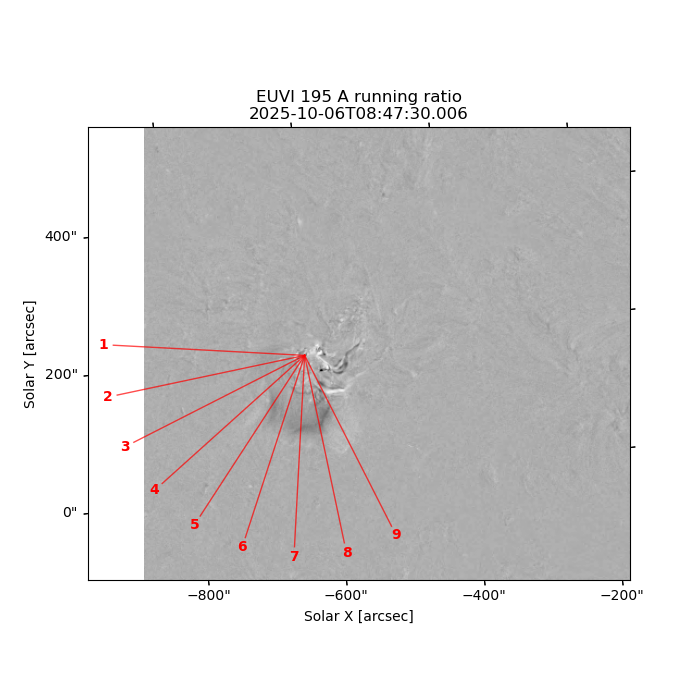

In [54]:
# Pick the sequence frame whose time is nearest REF_DATETIME.
ref_key = min(results['frames'],
              key=lambda k: abs(pd.to_datetime(k) - pd.to_datetime(REF_DATETIME)))
frame = results['frames'][ref_key]

savepath = os.path.join(FIG_DIR, f'euvi_slits_running_{METHOD}.png') if SAVE_FIGS else None
plot_map_with_slits(
    frame['cropped_map'], slits=results['slits'], method=METHOD,
    ratio_scale=RATIO_SCALE, diff_percentile=DIFF_PERCENTILE,
    title=f'EUVI {EUVI_CHANNEL} A running {METHOD}\n{frame["frame_time"]}',
    cmap='Greys_r', show_title=SHOW_TITLES, savepath=savepath, dpi=FIG_DPI)
plt.show()


### 3. Trace a feature on each slit

Run the store cell below **once** to create the shared dicts, then run the
interactive cell repeatedly: set `ACTIVE_SLIT_ID`, click out `N_REPEATS` traces,
change the id, repeat. Re-running the store cell wipes previous clicks.


In [55]:
clicked_traces = {}
jplot_times_by_slit = {}


Left click = add point.
Right click = save this trace and reset.


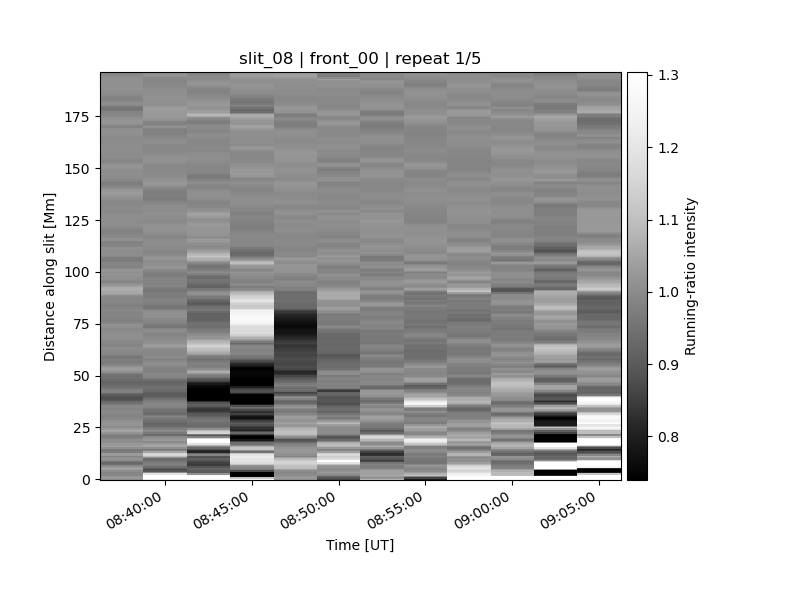

In [58]:
ACTIVE_SLIT_ID = 'slit_08'   # 1-based ids (slit_01 ... slit_NN); re-run per slit

fig, ax, jplot, jtimes, distances = plot_jplot(
    results, slit_id=ACTIVE_SLIT_ID, distance_unit=DISTANCE_UNIT,
    xlim=JPLOT_TLIM, ylim=JPLOT_DLIM, cmap=JPLOT_CMAP, show_title=SHOW_TITLES)

clicked_traces = collect_repeated_jplot_traces(
    fig, ax, slit_id=ACTIVE_SLIT_ID, feature_id=FEATURE_ID,
    n_repeats=N_REPEATS, storage=clicked_traces, y_unit=DISTANCE_UNIT,
    show_title=SHOW_TITLES)

jplot_times_by_slit[ACTIVE_SLIT_ID] = jtimes
plt.show()


In [ ]:
# # In case you want to redo a slit
# clicked_traces.pop('slit_07')
# jplot_times_by_slit.pop('slit_07')

### 4. Inspect the active slit (optional)

Overlay the mean trace on its J-plot and show the kinematics for whichever slit
`ACTIVE_SLIT_ID` currently points at.


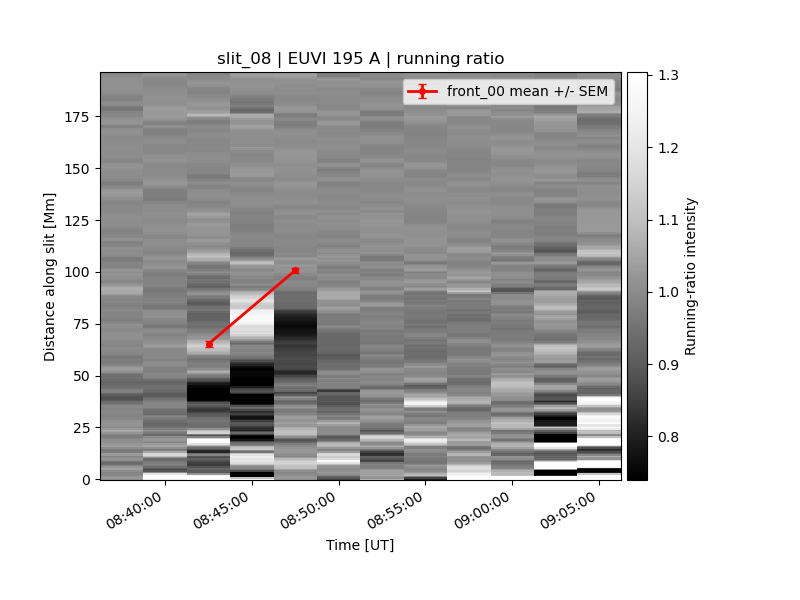

ValueError: Need more than 3 points for Savitzky-Golay smoothing.

In [59]:
trace_summary = summarise_repeated_traces(
    clicked_traces, slit_id=ACTIVE_SLIT_ID, feature_id=FEATURE_ID,
    jplot_times=jplot_times_by_slit[ACTIVE_SLIT_ID])

fig, ax, *_ = plot_jplot(
    results, slit_id=ACTIVE_SLIT_ID, distance_unit=DISTANCE_UNIT,
    xlim=JPLOT_TLIM, ylim=JPLOT_DLIM, cmap=JPLOT_CMAP, show_title=SHOW_TITLES)
overplot_trace_summary(ax, trace_summary, errorbar_every=2)
if SAVE_FIGS:
    save_fig(fig, os.path.join(FIG_DIR, f'{ACTIVE_SLIT_ID}_{FEATURE_ID}_jplot.png'), dpi=FIG_DPI)
plt.show()

kin = compute_trace_kinematics(
    trace_summary, smooth=True,
    savgol_window=SAVGOL_WINDOW, savgol_polyorder=SAVGOL_POLYORDER)
kin_prefix = os.path.join(FIG_DIR, f'{ACTIVE_SLIT_ID}_{FEATURE_ID}') if SAVE_FIGS else None
plot_trace_kinematics(kin, errorbar_every=1, show_title=SHOW_TITLES,
                      savepath_prefix=kin_prefix, dpi=FIG_DPI)
plt.show()

# Optional per-slit trace-summary CSV:
trace_summary_to_dataframe(trace_summary).to_csv(
    os.path.join(OUTPUT_DIR, f'{ACTIVE_SLIT_ID}_{FEATURE_ID}_trace_summary.csv'), index=False)


In [ ]:
# # In case you want to redo a slit
# clicked_traces.pop('slit_07')
# jplot_times_by_slit.pop('slit_07')


### 5. Aggregate every traced slit, save, and plot

Operates on whatever slits exist in `clicked_traces`, so it scales from one slit
to the whole fan without edits.


In [ ]:
traced_slit_ids = list(clicked_traces.keys())

all_kin = compute_kinematics_for_slits(
    clicked_traces=clicked_traces,
    slit_ids=traced_slit_ids,
    feature_id=FEATURE_ID,
    jplot_times_by_slit=jplot_times_by_slit,
    smooth=True, savgol_window=SAVGOL_WINDOW, savgol_polyorder=SAVGOL_POLYORDER)

# One CSV per slit.
for s in all_kin:
    slit_csv = os.path.join(OUTPUT_DIR, f'{s}_{FEATURE_ID}_kinematics.csv')
    kinematics_to_dataframe(all_kin[s]).to_csv(slit_csv, index=False)
    print(f'Saved {slit_csv}')

# Combined CSV (all slits stacked).
df_all_kin = pd.concat([kinematics_to_dataframe(all_kin[s]) for s in all_kin],
                       ignore_index=True)
out_csv = os.path.join(OUTPUT_DIR, f'all_slits_{FEATURE_ID}_kinematics_EUVI.csv')
df_all_kin.to_csv(out_csv, index=False)
print(f'Saved {out_csv}')
df_all_kin.head()


In [ ]:
sp_speed = os.path.join(FIG_DIR, f'all_slits_{FEATURE_ID}_speed_EUVI.png') if SAVE_FIGS else None
sp_acc   = os.path.join(FIG_DIR, f'all_slits_{FEATURE_ID}_acceleration_EUVI.png') if SAVE_FIGS else None

plot_all_slit_speeds(all_kin, errorbar_every=1, show_title=SHOW_TITLES, savepath=sp_speed, dpi=FIG_DPI)
plt.show()

plot_all_slit_accelerations(all_kin, errorbar_every=1, show_title=SHOW_TITLES, savepath=sp_acc, dpi=FIG_DPI)
plt.show()
